In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [15]:
class Dataset:
    def __init__(self, alpha=0.46, xmin=0, tmin=0, xmax=1, tmax=1, Nx=100, Nt=50, m=1, n=1):
        self.m, self.n = m, n
        self.alpha = alpha
        self.tmin, self.xmin = tmin, xmin
        self.tmax, self.xmax = tmax, xmax
        x1d = np.linspace(xmin, xmax, Nx)
        t1d = np.linspace(tmin, tmax, Nt)
        self.x, self.t = np.meshgrid(x1d, t1d)
        self.solution = self.calculate_solution(self.x, self.t)

    def calculate_solution(self, x, t):
        return np.exp((-(self.n**2)*(np.pi**2)*self.alpha*t)/(self.m**2)) * \
               np.sin(self.n*np.pi*x/self.m)

In [16]:
class SomeModel(nn.Module):
    """
    u(x, t)       — предсказывается сетью.
    alpha(x, t)   — предсказывается как softplus(alpha_base + NN(x,t)).
                    alpha_base — обучаемый СКАЛЯР (изначально 0.1).
                    NN-добавка мала (регуляризуем), что позволяет выучить константу.
    """
    def __init__(self, input_size=2, nnodes=64, nlayers=5):
        super().__init__()
        self.activation = nn.Tanh()

        self.dense0 = nn.Linear(input_size, nnodes)
        self.hidden_layers = nn.ModuleList([
            nn.Linear(nnodes, nnodes) for _ in range(nlayers - 1)
        ])

        self.head_u = nn.Linear(nnodes, 1)
        self.head_alpha = nn.Linear(nnodes, 1)

        self.alpha_base = nn.Parameter(torch.tensor(0.1))

        self.apply(self._init_weights_xavier)

    def _init_weights_xavier(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        if x.dtype == torch.float64:
            x = x.float()

        h = self.activation(self.dense0(x))
        for layer in self.hidden_layers:
            h = self.activation(layer(h))

        u = self.head_u(h)

        raw_add = self.head_alpha(h)
        alpha = torch.nn.functional.softplus(self.alpha_base + 0.1 * raw_add)

        return u, alpha

In [17]:
class Batch_bc:
    def __init__(self, x, t, values):
        x = x.flatten(); t = t.flatten(); values = values.flatten()
        self.grid = np.vstack((x, t)).T
        self.u = values.reshape(-1, 1)

    def generate_points(self, N):
        N = min(N, len(self.grid))
        indices = torch.randperm(len(self.grid))[:N]
        self.points = torch.from_numpy(self.grid[indices.numpy()]).float().to(device)
        self.values = torch.from_numpy(self.u[indices.numpy()]).float().to(device)
        self.points.requires_grad = True

class Batch:
    def __init__(self, data: Dataset):
        x = data.x.flatten(); t = data.t.flatten()
        self.grid = np.vstack((x, t)).T
        self.u = data.solution.reshape(-1, 1)

    def generate_points(self, N):
        N = min(N, len(self.grid))
        indices = torch.randperm(len(self.grid))[:N]
        idx = indices.numpy()
        self.points = torch.from_numpy(self.grid[idx]).float().to(device)
        self.values = torch.from_numpy(self.u[idx]).float().to(device)
        self.points.requires_grad = True

In [18]:
def PDE_loss(u, alpha, grid):
    """u_t = (alpha * u_x)_x  (дивергентная форма)"""
    grad_u = torch.autograd.grad(u, grid, torch.ones_like(u), create_graph=True, retain_graph=True)[0]
    ux = grad_u[:, 0:1]
    ut = grad_u[:, 1:2]
    uxx = torch.autograd.grad(ux, grid, torch.ones_like(ux), create_graph=True, retain_graph=True)[0][:, 0:1]

    grad_a = torch.autograd.grad(alpha, grid, torch.ones_like(alpha), create_graph=True, retain_graph=True)[0]
    ax = grad_a[:, 0:1]

    res = ut - (ax * ux + alpha * uxx)
    return torch.mean(res**2)

def data_loss(model, grid, sol):
    out_u, _ = model(grid)
    return torch.mean((sol - out_u)**2)

In [19]:
def train_pinn(model, train_batch, ic_batch, lb_batch, rb_batch,
               numEpoch=4000, warmup_epochs=1000):

    alpha_params = [model.alpha_base]
    other_params = [p for n, p in model.named_parameters() if n != 'alpha_base']

    opt_warmup = torch.optim.Adam(other_params, lr=1e-3)

    opt_full = torch.optim.Adam([
        {'params': other_params, 'lr': 1e-3},
        {'params': alpha_params, 'lr': 1e-3}
    ])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_full, mode='min', factor=0.7, patience=300)

    hist_loss, alpha_hist = [], []
    pbar = tqdm.tqdm(range(numEpoch), desc='Training')

    for step in pbar:
        train_batch.generate_points(1500)
        ic_batch.generate_points(300)
        lb_batch.generate_points(300)
        rb_batch.generate_points(300)

        def closure():

            opt = opt_warmup if step < warmup_epochs else opt_full
            opt.zero_grad()

            grid = train_batch.points
            out_u, out_alpha = model(grid)

            l_pde = PDE_loss(out_u, out_alpha, grid)

            l_data = data_loss(model, train_batch.points, train_batch.values)

            l_ic = data_loss(model, ic_batch.points, ic_batch.values)
            l_lb = data_loss(model, lb_batch.points, lb_batch.values)
            l_rb = data_loss(model, rb_batch.points, rb_batch.values)

            reg_alpha = 1e-4 * torch.mean((out_alpha - model.alpha_base)**2)

            loss = (1.0  * l_pde
                    + 30.0 * l_data
                    + 5.0  * l_ic
                    + 5.0  * l_lb
                    + 5.0  * l_rb
                    + reg_alpha)

            loss.backward()
            return loss

        current_loss = (opt_warmup if step < warmup_epochs else opt_full).step(closure)
        hist_loss.append(current_loss.item())

        with torch.no_grad():
            alpha_hist.append(model.alpha_base.item())

        if step >= warmup_epochs:
            scheduler.step(current_loss.item())

        if step % 200 == 0:
            phase = "warmup" if step < warmup_epochs else "full"
            pbar.set_description(f"[{phase}] {step} | Loss {current_loss:.6f} | α={model.alpha_base.item():.4f}")

    return hist_loss, alpha_hist

In [20]:
def run_experiment(Nx, Nt, true_alpha=0.46, numEpoch=4000):
    print(f"\n--- Сетка {Nx}x{Nt}, истинный alpha={true_alpha} ---")
    data = Dataset(alpha=true_alpha, Nx=Nx, Nt=Nt, m=1, n=1)

    train_batch = Batch(data)
    ic_batch = Batch_bc(data.x[0, :].reshape(-1, 1), data.t[0, :].reshape(-1, 1), data.solution[0, :].reshape(-1, 1))
    lb_batch = Batch_bc(data.x[:, 0].reshape(-1, 1), data.t[:, 0].reshape(-1, 1), data.solution[:, 0].reshape(-1, 1))
    rb_batch = Batch_bc(data.x[:, -1].reshape(-1, 1), data.t[:, -1].reshape(-1, 1), data.solution[:, -1].reshape(-1, 1))

    model = SomeModel(nnodes=64, nlayers=5).to(device)

    with torch.no_grad():
        model.alpha_base.fill_(0.1)
    print(f"Начальный alpha_base: {model.alpha_base.item():.4f}")

    hist_loss, alpha_hist = train_pinn(
        model, train_batch, ic_batch, lb_batch, rb_batch,
        numEpoch=numEpoch, warmup_epochs=1000
    )

    grid_pred = torch.from_numpy(np.column_stack([data.x.flatten(), data.t.flatten()])).float().to(device)
    with torch.no_grad():
        pred_u, pred_alpha = model(grid_pred)
        pred_u = pred_u.cpu().numpy().reshape(data.x.shape)
        pred_alpha_map = pred_alpha.cpu().numpy().reshape(data.x.shape)

    err_L2 = np.linalg.norm(pred_u - data.solution) / np.linalg.norm(data.solution)
    mean_a = pred_alpha_map.mean()
    print(f"L2 err: {err_L2:.4f} | alpha mean: {mean_a:.4f} | alpha_base: {model.alpha_base.item():.4f} | True: {true_alpha}")

    return data, pred_u, pred_alpha_map, hist_loss, alpha_hist, err_L2

In [21]:
data_det, pu_det, pa_det, loss_det, ah_det, err_det = run_experiment(Nx=100, Nt=50, true_alpha=0.46, numEpoch=4000)
data_coa, pu_coa, pa_coa, loss_coa, ah_coa, err_coa = run_experiment(Nx=10, Nt=5, true_alpha=0.46, numEpoch=4000)


--- Сетка 100x50, истинный alpha=0.46 ---
Начальный alpha_base: 0.1000


[full] 3800 | Loss 0.000524 | α=-0.0130: 100%|██████████| 4000/4000 [02:08<00:00, 31.12it/s]


L2 err: 0.0114 | alpha mean: 0.4595 | alpha_base: -0.0196 | True: 0.46

--- Сетка 10x5, истинный alpha=0.46 ---
Начальный alpha_base: 0.1000


[full] 3800 | Loss 0.000402 | α=0.0361: 100%|██████████| 4000/4000 [00:26<00:00, 153.55it/s]

L2 err: 0.0113 | alpha mean: 0.4495 | alpha_base: 0.0329 | True: 0.46


In [35]:
def plot_results(data, pred_u, pred_alpha, loss, ah, true_a, suffix="",
                 alpha_vmin=0.4, alpha_vmax=0.5,
                 u_vmin=None, u_vmax=None):

    fig, ax = plt.subplots(2, 3, figsize=(18, 10))

    u_kwargs = {}
    if u_vmin is not None and u_vmax is not None:
        u_kwargs = dict(vmin=u_vmin, vmax=u_vmax)

    f = ax[0, 0].pcolormesh(data.x, data.t, data.solution,
                            cmap='jet', shading='auto', **u_kwargs)
    plt.colorbar(f, ax=ax[0, 0])
    ax[0, 0].set_title(f'True u {suffix}')
    ax[0, 0].set_xlabel('x'); ax[0, 0].set_ylabel('t')

    f = ax[0, 1].pcolormesh(data.x, data.t, pred_u,
                            cmap='jet', shading='auto', **u_kwargs)
    plt.colorbar(f, ax=ax[0, 1])
    ax[0, 1].set_title('Pred u')
    ax[0, 1].set_xlabel('x'); ax[0, 1].set_ylabel('t')

    f = ax[0, 2].pcolormesh(data.x, data.t, np.abs(pred_u - data.solution),
                            cmap='jet', shading='auto')
    plt.colorbar(f, ax=ax[0, 2])
    ax[0, 2].set_title('|pred - true|')
    ax[0, 2].set_xlabel('x'); ax[0, 2].set_ylabel('t')

    f = ax[1, 0].pcolormesh(
        data.x, data.t, pred_alpha,
        cmap='coolwarm', shading='auto',
        vmin=alpha_vmin, vmax=alpha_vmax
    )
    plt.colorbar(f, ax=ax[1, 0])
    ax[1, 0].set_title(f'Карта alpha(x,t) {suffix} (истина={true_a})')
    ax[1, 0].set_xlabel('x'); ax[1, 0].set_ylabel('t')

    ax[1, 1].plot(loss)
    ax[1, 1].set_yscale('log')
    ax[1, 1].set_title('Loss history'); ax[1, 1].set_xlabel('epoch')

    ax[1, 2].plot(ah, color='b', label='α_base')
    ax[1, 2].axhline(y=true_a, color='r', linestyle='--',
                     label=f'True={true_a}')
    ax[1, 2].set_ylim(alpha_vmin, alpha_vmax)
    ax[1, 2].set_title('Сходимость α_base')
    ax[1, 2].set_xlabel('epoch'); ax[1, 2].legend()

    plt.tight_layout()
    plt.show()

=== Результаты (100x50) ===


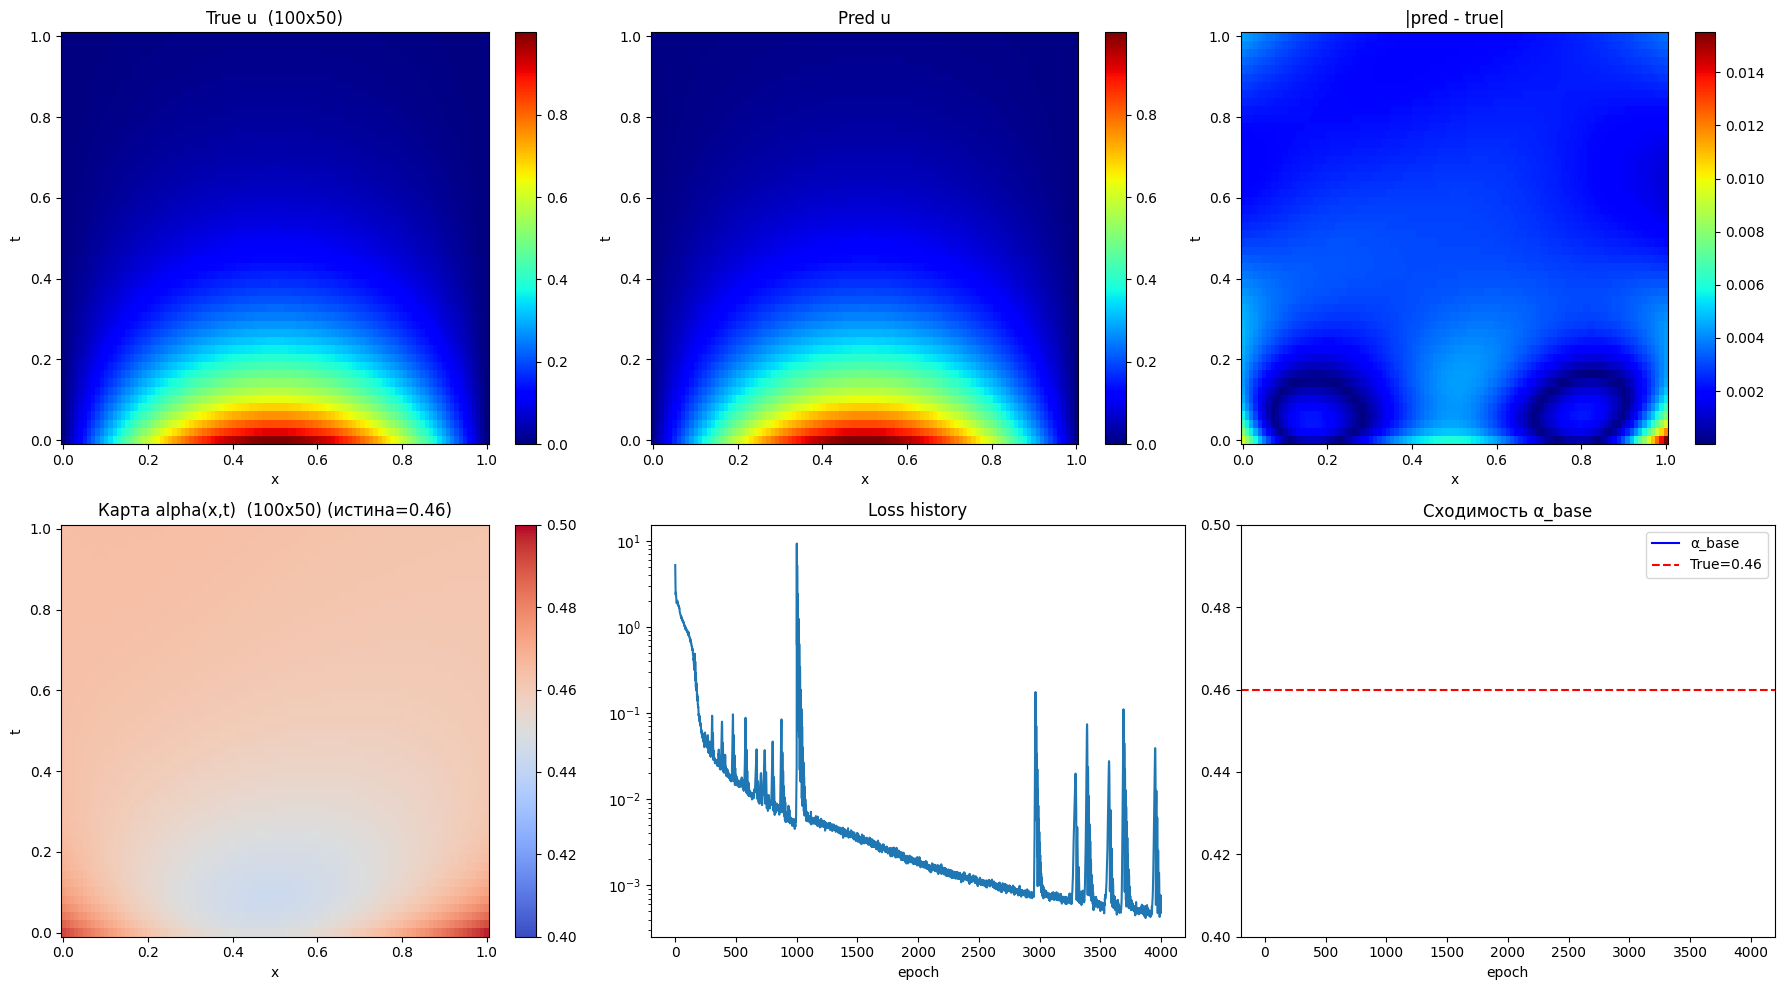

=== Результаты (10x5) ===


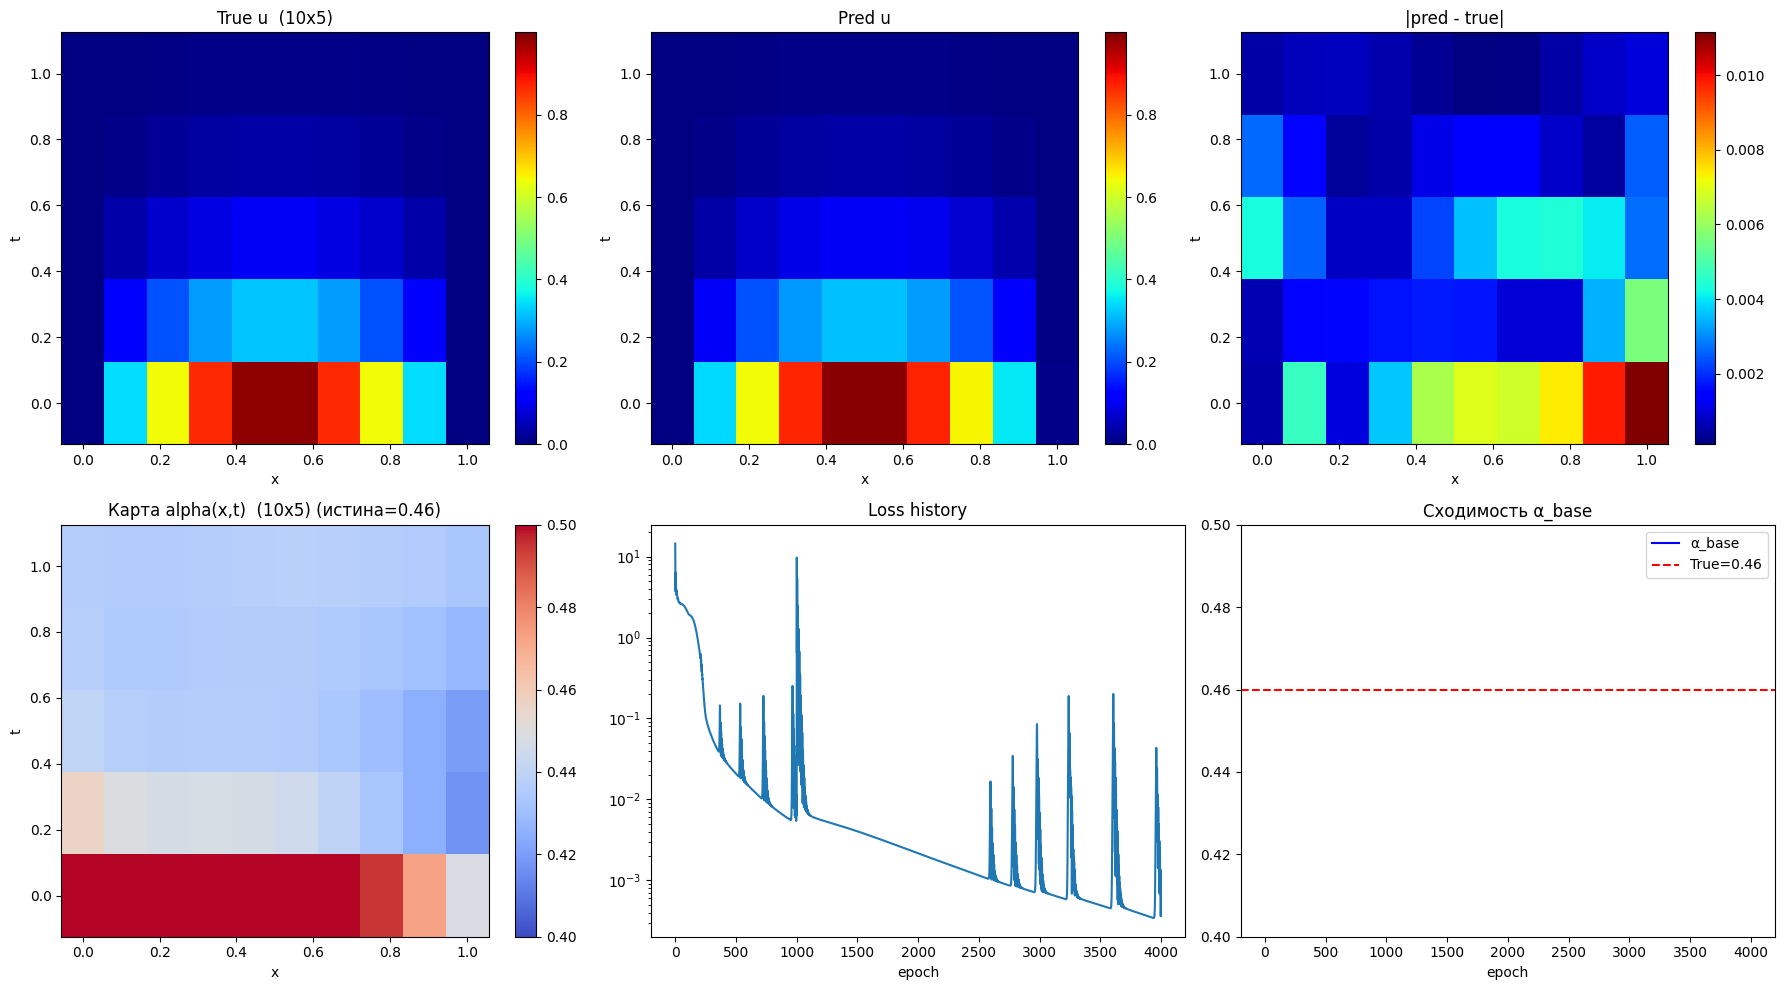

In [36]:
print("=== Результаты (100x50) ===")
u_min = float(data_det.solution.min())
u_max = float(data_det.solution.max())
plot_results(data_det, pu_det, pa_det, loss_det, ah_det, 0.46,
             " (100x50)", alpha_vmin=0.4, alpha_vmax=0.5,
             u_vmin=u_min, u_vmax=u_max)

print("=== Результаты (10x5) ===")
plot_results(data_coa, pu_coa, pa_coa, loss_coa, ah_coa, 0.46,
             " (10x5)", alpha_vmin=0.4, alpha_vmax=0.5,
             u_vmin=u_min, u_vmax=u_max)